# VAE Results Browser

Load a trained 2D or 3D VAE checkpoint, rebuild the dataset from the run configuration, and inspect reconstructions plus latent maps. Set `RUN_DIR` in the next cell to a run folder containing `best_model.pth` or `ckpt.pth`.


In [1]:
from pathlib import Path
import csv
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from torch.utils.data import DataLoader


def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "setup.py").exists() and (path / "diffusionsr").exists():
            return path
    raise RuntimeError("Could not find LPBFDiffusionSR project root")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from diffusionsr.datasets.dataset import SimulationXZDataset
from diffusionsr.models.vae_model import VAE2D, VAE3D, vae_loss

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_ROOT, DEVICE


(PosixPath('/home/shohom-tfc/src/LPBFDiffusionSR'), device(type='cuda'))

## Choose A Run

`RUN_DIR` should point at a VAE run directory. Current runners usually save under `diffusionsr/runs/...` when launched from `diffusionsr/`.


In [2]:
RUN_DIR = PROJECT_ROOT / "diffusionsr" / "runs" / "direct" / "vae2d" / "2026_05_18_15_08_05" / "standardize" / "n_steps_1"
RUN_DIR = "/home/shohom-tfc/src/LPBFDiffusionSR/diffusionsr/runs/direct/vae3d/2026_06_03_08_34_00/standardize/n_steps_1"#"/home/shohom-tfc/src/LPBFDiffusionSR/diffusionsr/runs/direct/vae3d/2026_05_18_20_23_00/standardize/n_steps_1"
MULTIFIELD_VAE_RUN_DIR = PROJECT_ROOT / "diffusionsr" / "runs" / "direct" / "vae3d" / "2026_06_03_08_34_00" / "standardize" / "n_steps_1"
# RUN_DIR = MULTIFIELD_VAE_RUN_DIR
CHECKPOINT_NAME = "best_model.pth"  # or "ckpt.pth"
DATA_SPLIT = "test"  # "dev" is often useful if test stats/data are not present yet
BATCH_SIZE = 1
BATCH_INDEX = 30
SAMPLE_INDEX = 0
CHANNEL_INDEX = 0
LATENT_CHANNEL_INDEX = 0
DEPTH_INDEX = None  # None uses the center depth slice for 3D
EXPORT_LATENTS = False

RUN_DIR = Path(RUN_DIR).expanduser().resolve()
CHECKPOINT_PATH = RUN_DIR / CHECKPOINT_NAME
CONFIG_PATH = RUN_DIR / "configuration.yml"
assert RUN_DIR.exists(), f"Missing run directory: {RUN_DIR}"
assert CHECKPOINT_PATH.exists(), f"Missing checkpoint: {CHECKPOINT_PATH}"
assert CONFIG_PATH.exists(), f"Missing copied config: {CONFIG_PATH}"
RUN_DIR


PosixPath('/home/shohom-tfc/src/LPBFDiffusionSR/diffusionsr/runs/direct/vae3d/2026_06_03_08_34_00/standardize/n_steps_1')

In [3]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

model_config = checkpoint["model_config"]
trainer_config = checkpoint.get("trainer_config", {})
spatial_dims = int(model_config.get("spatial_dims", trainer_config.get("spatial_dims", 2)))
model_cls = VAE2D if spatial_dims == 2 else VAE3D

model = model_cls(
    input_channels=int(model_config["input_channels"]),
    output_channels=int(model_config.get("output_channels", model_config["input_channels"])),
    latent_channels=int(model_config["latent_channels"]),
    hidden_channels=int(model_config["hidden_channels"]),
    channel_multipliers=tuple(model_config["channel_multipliers"]),
    output_activation=model_config.get("output_activation"),
).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(json.dumps({"checkpoint": str(CHECKPOINT_PATH), "saved_at": checkpoint.get("saved_at"), "model_config": model_config, "trainer_config": trainer_config}, indent=2, default=str))


{
  "checkpoint": "/home/shohom-tfc/src/LPBFDiffusionSR/diffusionsr/runs/direct/vae3d/2026_06_03_08_34_00/standardize/n_steps_1/best_model.pth",
  "saved_at": "2026-06-03T18:19:00",
  "model_config": {
    "spatial_dims": 3,
    "input_channels": 3,
    "output_channels": 3,
    "latent_channels": 8,
    "hidden_channels": 32,
    "channel_multipliers": [
      1,
      2,
      4
    ],
    "output_activation": null,
    "min_logvar": -30.0,
    "max_logvar": 20.0
  },
  "trainer_config": {
    "spatial_dims": 3,
    "input_type": "upscaled_lr",
    "target_type": "upscaled_lr",
    "depth_size": 1,
    "beta": 1e-06,
    "reconstruction_loss": "l1",
    "kl_anneal_epochs": 0,
    "num_workers": 0,
    "log_interval": 5,
    "sample_interval": 5,
    "save_every": 0,
    "grad_clip_norm": null
  }
}


## Rebuild Dataset

This uses `SimulationXZDataset` and the copied config. For future real 3D data, replace this cell with the true-volume dataset as long as it returns `(residual, hr, true_lr, upscaled_lr)` and gives the trainer/model tensors shaped `(B, C, D, H, W)`.


In [4]:
def config_to_field_names(config_dict):
    fields = config_dict.get("fields")
    field_aliases = {"melt_region": "meltregion"}
    if fields == "temperature":
        return ["temperature"]
    if fields == "temperature_liqlabel":
        return ["temperature", "liqlabel"]
    if fields in ["temperature_liqlabel_meltregion", "temperature_liqlabel_melt_region"]:
        return ["temperature", "liqlabel", "meltregion"]
    if fields == "all_but_pressure":
        return ["vx", "temperature", "vy", "vz", "liqlabel"]
    if fields in ["all", None]:
        return None
    if isinstance(fields, (list, tuple)):
        return [field_aliases.get(field, field) for field in fields]
    raise ValueError(f"Unsupported fields config: {fields}")


def resolve_root_folder(config_dict):
    root_folder = Path(config_dict["root_folder"]).expanduser()
    if root_folder.is_absolute():
        return str(root_folder)
    project_relative = PROJECT_ROOT / root_folder
    if project_relative.exists():
        return str(project_relative)
    diffusionsr_relative = PROJECT_ROOT / "diffusionsr" / root_folder
    if diffusionsr_relative.exists():
        return str(diffusionsr_relative)
    return str(project_relative)


def canonical_data_type(data_type):
    aliases = {"high_resolution": "hr", "true_lr": "lr"}
    return aliases.get(data_type, data_type)


def _select_stats(dataset, input_type):
    input_type = canonical_data_type(input_type)
    if input_type == "hr":
        mean = dataset.mean_hr
        std = dataset.std_hr
    elif input_type == "lr":
        mean = dataset.mean_lr
        std = dataset.std_lr
    elif input_type == "upscaled_lr":
        mean = dataset.mean_upscaled_lr
        std = dataset.std_upscaled_lr
    elif input_type == "residual":
        mean = dataset.mean_resid
        std = dataset.std_resid
    else:
        raise ValueError(f"Unsupported input_type: {input_type}")
    return np.asarray(mean), np.asarray(std)


def unscale_volume(dataset, volume, input_type):
    """Match notebook 05: unscale fake-depth 3D volumes back to physical units."""
    input_type = canonical_data_type(input_type)
    volume = np.asarray(volume)
    channels, depth, height, width = volume.shape
    flat = volume.reshape(channels * depth, height, width)

    if getattr(dataset, "normalize", None) == "rescaling":
        unscaled = np.asarray(dataset.unscale_data(flat, input_type=input_type))
        return unscaled.reshape(channels, depth, height, width)

    mean, std = _select_stats(dataset, input_type)

    # Older stats folders are 2D-only, so broadcast the single-field stats
    # across inflated depth slices used for fake-3D visualization.
    if mean.ndim == 2:
        mean = np.broadcast_to(mean, (channels * depth, height, width))
        std = np.broadcast_to(std, (channels * depth, height, width))
        return (flat * std + mean).reshape(channels, depth, height, width)

    if mean.ndim == 3:
        unscaled = np.asarray(dataset.unscale_data(flat, input_type=input_type))
        return unscaled.reshape(channels, depth, height, width)

    if mean.ndim == 4:
        return volume * std + mean

    raise ValueError(f"Unexpected stats rank for {input_type}: {mean.ndim}")


def unscale_tensor_batch(dataset, tensor, input_type):
    input_type = canonical_data_type(input_type)
    array = tensor.detach().cpu().numpy() if torch.is_tensor(tensor) else np.asarray(tensor)
    if spatial_dims == 2:
        return np.asarray(dataset.unscale_data(array, input_type=input_type))
    return np.stack([unscale_volume(dataset, sample, input_type=input_type) for sample in array], axis=0)


inflate_dim = config.get("inflate_dim") if spatial_dims == 3 else None
dataset = SimulationXZDataset(
    downscale_method=config["downscale_method"],
    root_folder=resolve_root_folder(config),
    split=DATA_SPLIT,
    normalize=config["normalize_method"],
    n_steps=int(config.get("n_steps", 1)),
    field_names=config_to_field_names(config),
    out_steps=config.get("out_steps"),
    inflate_dim=inflate_dim,
    inflate_method=config.get("inflate_method", "repeat"),
)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
print({
    "split": DATA_SPLIT,
    "samples": len(dataset),
    "spatial_dims": spatial_dims,
    "inflate_dim": inflate_dim,
    "input": trainer_config.get("input_type", config.get("vae_input_type", config.get("vae_input", config.get("vae_target", "hr")))),
    "target": trainer_config.get("target_type", config.get("vae_target", "hr")),
    "normalize": dataset.normalize,
})


Using normalize method: ... standardize
Using specific fields, ['temperature', 'liqlabel', 'meltregion']
Processing dataset with 3 fields
Downscale factor:  4
{'split': 'test', 'samples': 403, 'spatial_dims': 3, 'inflate_dim': None, 'input': 'upscaled_lr', 'target': 'upscaled_lr', 'normalize': 'standardize'}


In [5]:
TARGET_INDEX = {"residual": 0, "hr": 1, "high_resolution": 1, "lr": 2, "true_lr": 2, "upscaled_lr": 3}
target_type = trainer_config.get("target_type", config.get("vae_target", "hr"))
input_type = trainer_config.get("input_type", config.get("vae_input_type", config.get("vae_input", target_type)))
depth_size = int(trainer_config.get("depth_size") or config.get("inflate_dim") or 1)


def format_tensor(tensor):
    if spatial_dims == 2:
        if tensor.ndim == 3:
            return tensor.unsqueeze(1)
        return tensor
    if tensor.ndim == 5:
        return tensor
    if tensor.ndim != 4:
        raise ValueError(f"Expected flattened 3D tensor with shape (B, C*D, H, W) or real 5D tensor, got {tuple(tensor.shape)}")
    batch_size, channels, height, width = tensor.shape
    if channels % depth_size != 0:
        raise ValueError(f"Channel count {channels} is not divisible by depth size {depth_size}")
    return tensor.reshape(batch_size, channels // depth_size, depth_size, height, width)


def get_batch(loader, batch_index):
    for idx, batch in enumerate(loader):
        if idx == batch_index:
            return batch
    raise IndexError(f"Batch index {batch_index} is outside loader with {len(loader)} batches")

batch = get_batch(loader, BATCH_INDEX)
model_input = format_tensor(batch[TARGET_INDEX[input_type]]).to(DEVICE).float()
target = format_tensor(batch[TARGET_INDEX[target_type]]).to(DEVICE).float()
with torch.no_grad():
    output = model(
        model_input,
        sample_posterior=False,
        output_shape=target.shape[-spatial_dims:],
    )
    losses = vae_loss(
        output,
        target,
        beta=float(trainer_config.get("beta", config.get("vae_beta", 1e-4))),
        loss_type=trainer_config.get("reconstruction_loss", config.get("vae_reconstruction_loss", "l1")),
    )

model_input_unscaled = unscale_tensor_batch(dataset, model_input, input_type)
target_unscaled = unscale_tensor_batch(dataset, target, target_type)
reconstruction_unscaled = unscale_tensor_batch(dataset, output.reconstruction, target_type)

print({name: float(value.detach().cpu()) for name, value in losses.items()})
print({
    "input_type": input_type,
    "target_type": target_type,
    "input_shape": tuple(model_input.shape),
    "target_shape": tuple(target.shape),
    "reconstruction_shape": tuple(output.reconstruction.shape),
    "latent_shape": tuple(output.mu.shape),
    "target_unscaled_range": (float(np.nanmin(target_unscaled)), float(np.nanmax(target_unscaled))),
    "reconstruction_unscaled_range": (float(np.nanmin(reconstruction_unscaled)), float(np.nanmax(reconstruction_unscaled))),
})


{'loss': 0.0016167429275810719, 'reconstruction_loss': 0.0016117881750687957, 'kl_loss': 4.954712867736816}
{'input_type': 'upscaled_lr', 'target_type': 'upscaled_lr', 'input_shape': (1, 3, 160, 64, 64), 'target_shape': (1, 3, 160, 64, 64), 'reconstruction_shape': (1, 3, 160, 64, 64), 'latent_shape': (1, 8, 20, 8, 8), 'target_unscaled_range': (-1.862645149230957e-09, 3553.530029296875), 'reconstruction_unscaled_range': (-0.009164692834019661, 3540.869140625)}


## Reconstruction View

The images below are unscaled back to physical/original units using the same dataset statistics pattern as notebook 05. For temperature fields, the display defaults to the notebook 05 range of roughly 298-5000 K.


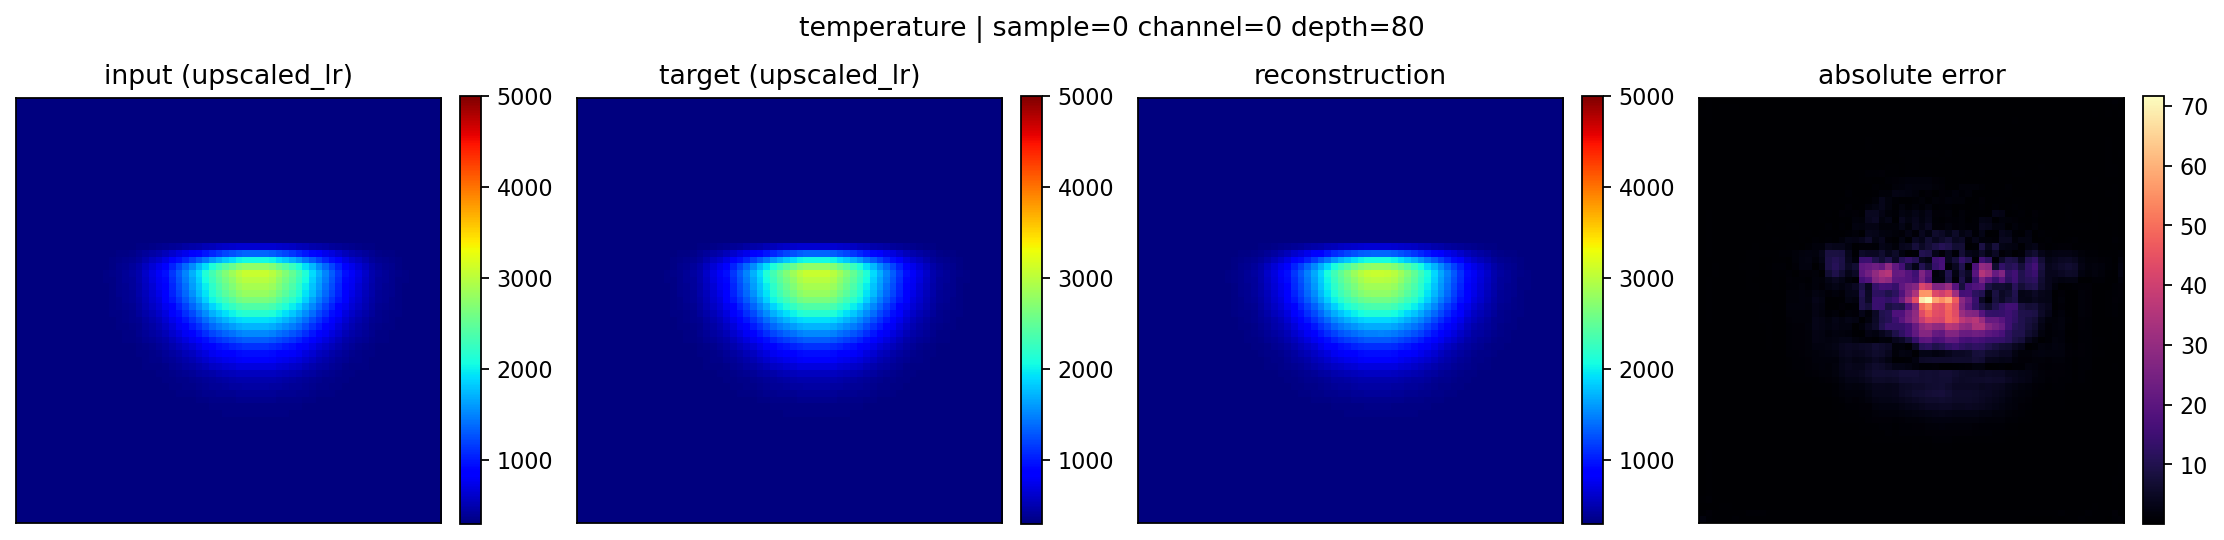

In [6]:
def display_slice(data, sample_index=0, channel_index=0, depth_index=None):
    array = data.detach().cpu().numpy() if torch.is_tensor(data) else np.asarray(data)
    sample_index = max(0, min(array.shape[0] - 1, int(sample_index)))
    channel_index = max(0, min(array.shape[1] - 1, int(channel_index)))
    image = array[sample_index, channel_index]
    if spatial_dims == 3:
        depth = image.shape[0]
        idx = depth // 2 if depth_index is None else int(depth_index)
        idx = max(0, min(depth - 1, idx))
        return image[idx], idx, sample_index, channel_index
    return image, None, sample_index, channel_index


def display_settings(dataset, data_type, channel_index):
    data_type = canonical_data_type(data_type)
    field_names = getattr(dataset, "field_names", []) or []
    field_name = field_names[channel_index % len(field_names)] if field_names else "field"
    if data_type != "residual" and field_name == "temperature":
        return "jet", 298.0, 5000.0, field_name
    if field_name in ["liqlabel", "meltregion"]:
        return "gray", 0.0, 1.0, field_name
    return "viridis", None, None, field_name


input_slice, input_depth, sample_idx, input_channel_idx = display_slice(
    model_input_unscaled,
    SAMPLE_INDEX,
    CHANNEL_INDEX,
    DEPTH_INDEX,
)
target_slice, used_depth, sample_idx, target_channel_idx = display_slice(
    target_unscaled,
    SAMPLE_INDEX,
    CHANNEL_INDEX,
    DEPTH_INDEX,
)
recon_slice, _, _, _ = display_slice(
    reconstruction_unscaled,
    SAMPLE_INDEX,
    CHANNEL_INDEX,
    DEPTH_INDEX,
)
error_slice = np.abs(recon_slice - target_slice)

cmap, vmin, vmax, field_name = display_settings(dataset, target_type, target_channel_idx)
input_cmap, input_vmin, input_vmax, input_field_name = display_settings(dataset, input_type, input_channel_idx)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), dpi=160)
panels = [
    (f"input ({input_type})", input_slice, input_cmap, input_vmin, input_vmax),
    (f"target ({target_type})", target_slice, cmap, vmin, vmax),
    ("reconstruction", recon_slice, cmap, vmin, vmax),
    ("absolute error", error_slice, "magma", None, None),
]
for ax, (title, array, panel_cmap, panel_vmin, panel_vmax) in zip(axes, panels):
    im = ax.imshow(array.T, origin="lower", cmap=panel_cmap, vmin=panel_vmin, vmax=panel_vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(
    f"{field_name} | sample={sample_idx} channel={target_channel_idx}"
    + (f" depth={used_depth}" if used_depth is not None else "")
)
fig.tight_layout()
plt.show()


## 3D Volume Slice Review

Orthogonal slices and max projections for the selected VAE volume, following the processed-3D review notebook layout.

In [7]:
# Controls for the 3D review cells below. These mirror the processed-3D review notebook.
VOLUME_SOURCE = "reconstruction"  # "input", "target", "reconstruction", or "error"
VOLUME_SAMPLE_INDEX = SAMPLE_INDEX
VOLUME_CHANNEL_INDEX = CHANNEL_INDEX
VOLUME_AXIS = "z"  # "x", "y", or "z"
VOLUME_SLICE_COUNT = 8
USE_PERCENTILE_COLOR_LIMITS = True


def center_indices(shape):
    return tuple(int(size // 2) for size in shape)


def slice_2d(array, axis, index):
    array = np.asarray(array)
    axis = axis.lower()
    if axis == "x":
        return array[index, :, :].T
    if axis == "y":
        return array[:, index, :].T
    if axis == "z":
        return array[:, :, index].T
    raise ValueError("axis must be x, y, or z")


def field_name_for_channel(dataset, channel_index):
    field_names = getattr(dataset, "field_names", []) or []
    if field_names:
        return field_names[int(channel_index) % len(field_names)]
    return "field"


def clamp_index(index, size):
    return max(0, min(int(size) - 1, int(index)))


def sample_channel_volume(data, sample_index=0, channel_index=0):
    array = data.detach().cpu().numpy() if torch.is_tensor(data) else np.asarray(data)
    if array.ndim != 5:
        raise ValueError(f"Expected a 5D batch (B, C, X, Y, Z) for 3D review, got {array.shape}")
    sample_index = clamp_index(sample_index, array.shape[0])
    channel_index = clamp_index(channel_index, array.shape[1])
    return np.asarray(array[sample_index, channel_index]), sample_index, channel_index


def center_crop_to_common(*volumes):
    common_shape = tuple(min(volume.shape[axis] for volume in volumes) for axis in range(3))
    cropped = []
    for volume in volumes:
        starts = [(volume.shape[axis] - common_shape[axis]) // 2 for axis in range(3)]
        slices = tuple(slice(start, start + size) for start, size in zip(starts, common_shape))
        cropped.append(volume[slices])
    return cropped


def finite_percentile_limits(volumes, percentiles=(1, 99)):
    values = []
    for volume in volumes:
        finite = np.asarray(volume)[np.isfinite(volume)]
        if finite.size:
            values.append(finite.ravel())
    if not values:
        return None, None
    vmin, vmax = np.nanpercentile(np.concatenate(values), percentiles)
    if np.isclose(vmin, vmax):
        return None, None
    return float(vmin), float(vmax)


def volume_plot_settings(dataset, data_type, channel_index, volumes=None, error=False):
    field_name = field_name_for_channel(dataset, channel_index)
    if error:
        return "magma", 0.0, finite_percentile_limits(volumes or [], (99, 99))[1], field_name
    if field_name == "temperature":
        if USE_PERCENTILE_COLOR_LIMITS and volumes is not None:
            vmin, vmax = finite_percentile_limits(volumes, (1, 99))
        elif canonical_data_type(data_type) != "residual":
            vmin, vmax = 298.0, 5000.0
        else:
            vmin, vmax = None, None
        return "inferno", vmin, vmax, field_name
    if field_name in ["liqlabel", "meltregion"]:
        return "gray", 0.0, 1.0, field_name
    return "viridis", None, None, field_name


def resolve_volume_source(source, sample_index=0, channel_index=0):
    source = source.lower()
    if source == "input":
        volume, sample_index, channel_index = sample_channel_volume(model_input_unscaled, sample_index, channel_index)
        return volume, source, input_type, sample_index, channel_index, False
    if source == "target":
        volume, sample_index, channel_index = sample_channel_volume(target_unscaled, sample_index, channel_index)
        return volume, source, target_type, sample_index, channel_index, False
    if source == "reconstruction":
        volume, sample_index, channel_index = sample_channel_volume(reconstruction_unscaled, sample_index, channel_index)
        return volume, source, target_type, sample_index, channel_index, False
    if source == "error":
        target_volume, sample_index, channel_index = sample_channel_volume(target_unscaled, sample_index, channel_index)
        recon_volume, _, _ = sample_channel_volume(reconstruction_unscaled, sample_index, channel_index)
        target_volume, recon_volume = center_crop_to_common(target_volume, recon_volume)
        return np.abs(recon_volume - target_volume), "absolute error", target_type, sample_index, channel_index, True
    raise ValueError("source must be input, target, reconstruction, or error")


def plot_vae_orthogonal_slices(source="reconstruction", sample_index=0, channel_index=0):
    if spatial_dims != 3:
        print("3D orthogonal slices are available only for VAE3D runs.")
        return
    volume, label, data_type, sample_index, channel_index, is_error = resolve_volume_source(source, sample_index, channel_index)
    cx, cy, cz = center_indices(volume.shape)
    images = [slice_2d(volume, "x", cx), slice_2d(volume, "y", cy), slice_2d(volume, "z", cz)]
    labels = [f"x={cx}", f"y={cy}", f"z={cz}"]
    cmap, vmin, vmax, field_name = volume_plot_settings(dataset, data_type, channel_index, [volume], error=is_error)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), dpi=160, constrained_layout=True)
    for ax, image, axis_label in zip(axes, images, labels):
        im = ax.imshow(image, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(axis_label)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"{label} | {field_name} | sample={sample_index} channel={channel_index} | shape={volume.shape}", y=1.05)
    plt.show()


def plot_vae_max_projections(source="reconstruction", sample_index=0, channel_index=0):
    if spatial_dims != 3:
        print("3D max projections are available only for VAE3D runs.")
        return
    volume, label, data_type, sample_index, channel_index, is_error = resolve_volume_source(source, sample_index, channel_index)
    projections = [volume.max(axis=0).T, volume.max(axis=1).T, volume.max(axis=2).T]
    labels = ["max over x", "max over y", "max over z"]
    cmap, vmin, vmax, field_name = volume_plot_settings(dataset, data_type, channel_index, [volume], error=is_error)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), dpi=160, constrained_layout=True)
    for ax, image, axis_label in zip(axes, projections, labels):
        im = ax.imshow(image, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(axis_label)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"{label} projections | {field_name} | sample={sample_index} channel={channel_index}", y=1.05)
    plt.show()


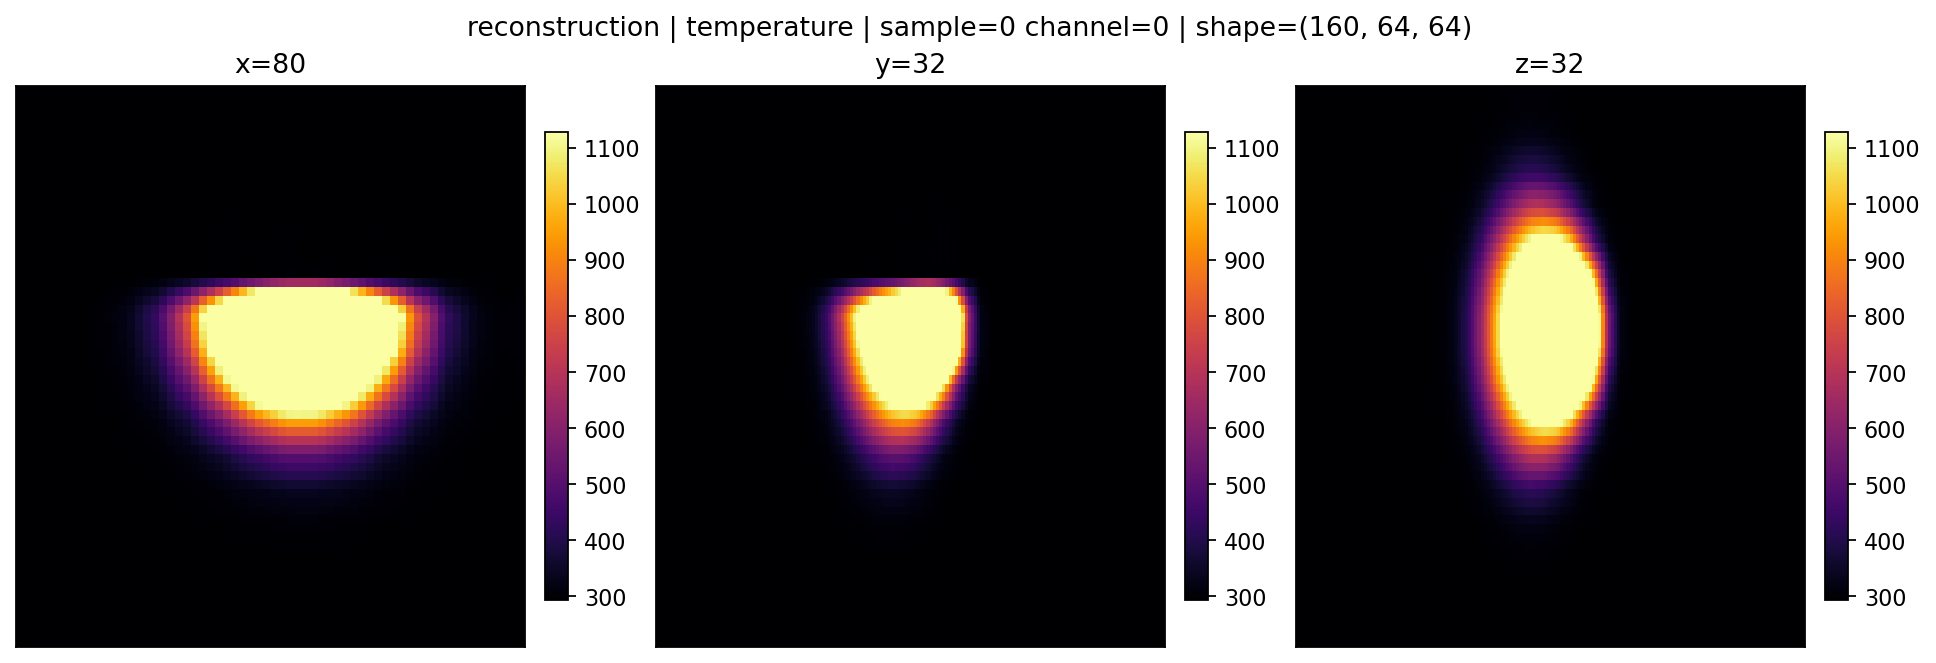

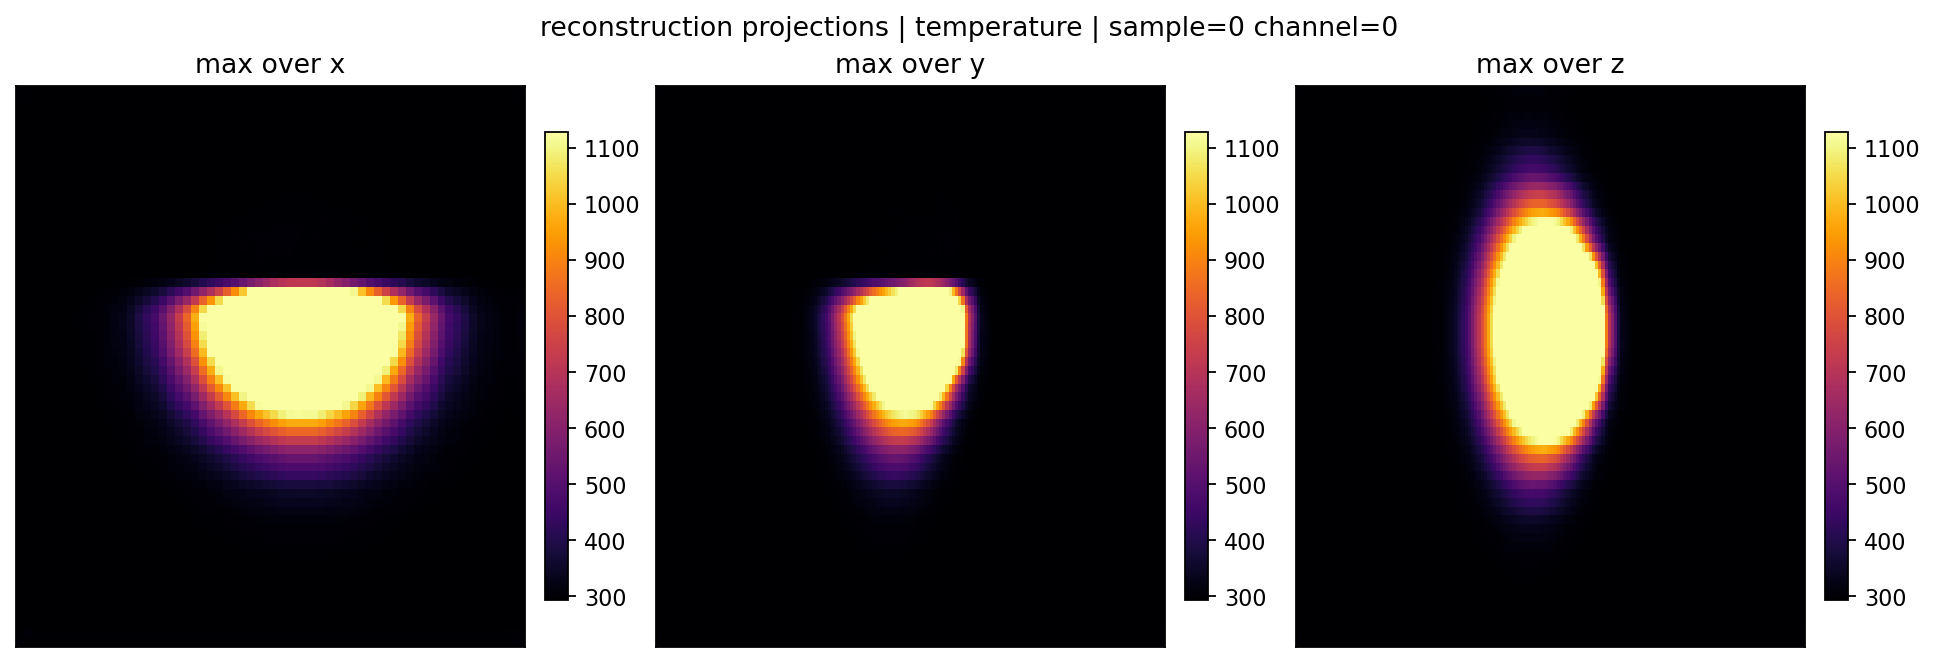

In [8]:
plot_vae_orthogonal_slices(
    source=VOLUME_SOURCE,
    sample_index=VOLUME_SAMPLE_INDEX,
    channel_index=VOLUME_CHANNEL_INDEX,
)
plot_vae_max_projections(
    source=VOLUME_SOURCE,
    sample_index=VOLUME_SAMPLE_INDEX,
    channel_index=VOLUME_CHANNEL_INDEX,
)


## 3D Input / Target / Reconstruction

Side-by-side center slices for the model input, reconstruction target, VAE reconstruction, and absolute error.

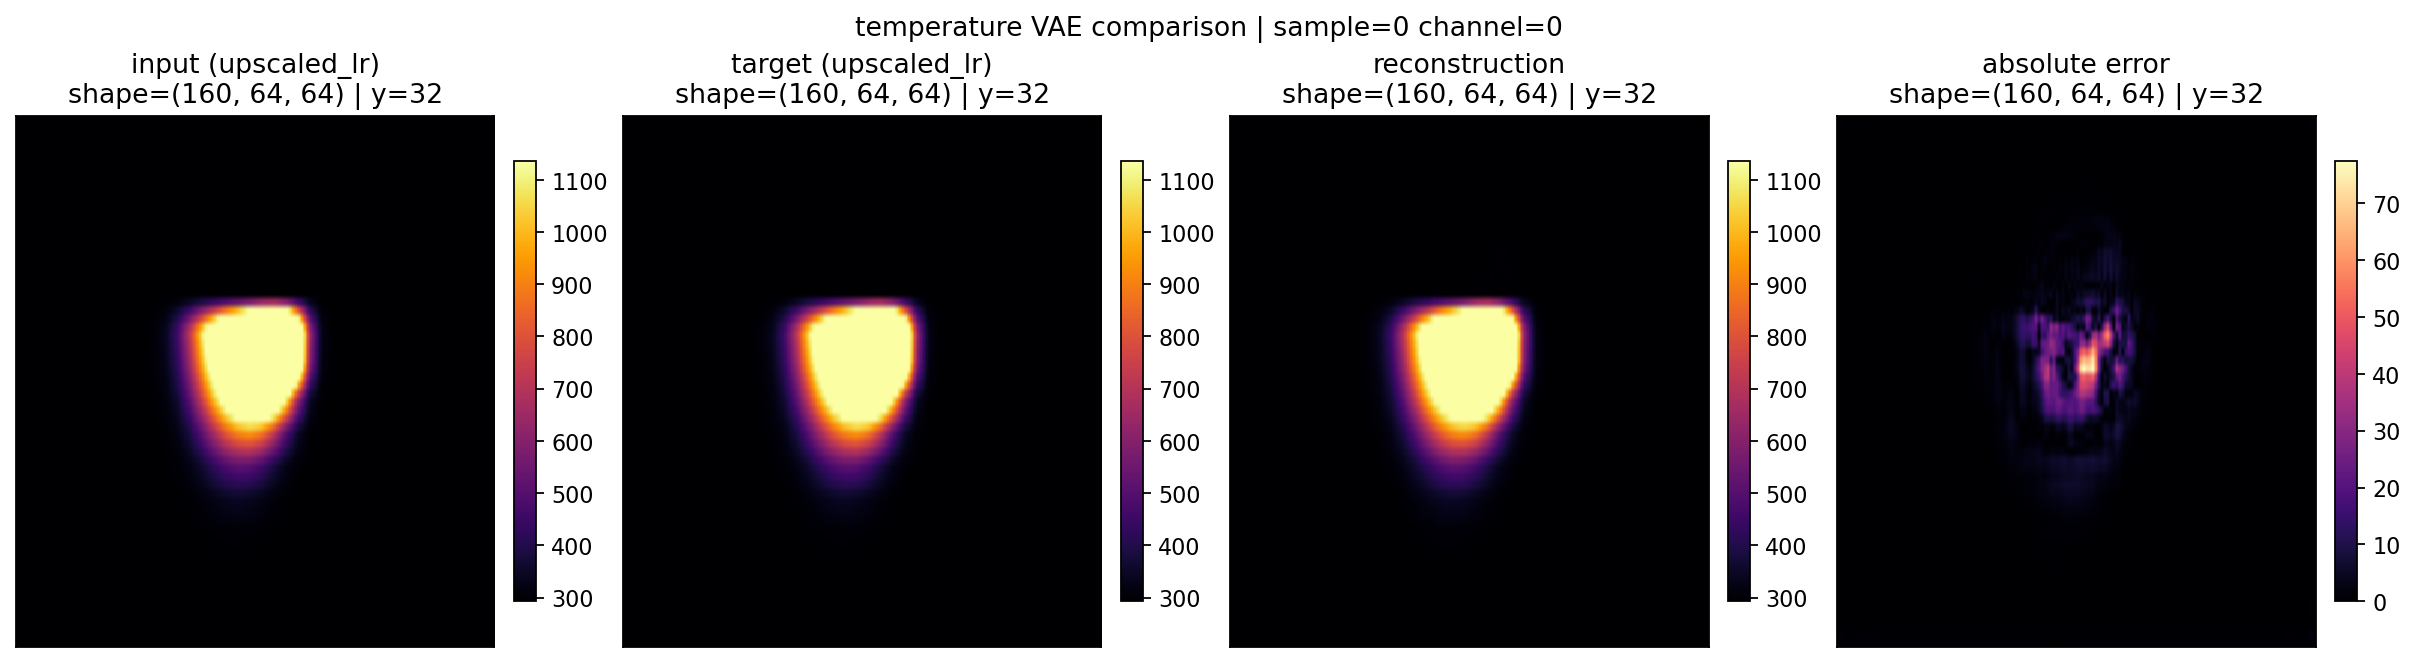

In [9]:
def plot_vae_volume_comparison(axis="z", sample_index=0, channel_index=0):
    if spatial_dims != 3:
        print("3D comparison slices are available only for VAE3D runs.")
        return
    input_volume, sample_index, input_channel = sample_channel_volume(model_input_unscaled, sample_index, channel_index)
    target_volume, sample_index, target_channel = sample_channel_volume(target_unscaled, sample_index, channel_index)
    recon_volume, _, _ = sample_channel_volume(reconstruction_unscaled, sample_index, target_channel)
    target_for_error, recon_for_error = center_crop_to_common(target_volume, recon_volume)
    error_volume = np.abs(recon_for_error - target_for_error)

    axis = axis.lower()
    axis_index = {"x": 0, "y": 1, "z": 2}[axis]
    shared_cmap, shared_vmin, shared_vmax, field_name = volume_plot_settings(
        dataset,
        target_type,
        target_channel,
        [input_volume, target_volume, recon_volume],
    )
    err_cmap, err_vmin, err_vmax, _ = volume_plot_settings(dataset, target_type, target_channel, [error_volume], error=True)
    panels = [
        (f"input ({input_type})", input_volume, shared_cmap, shared_vmin, shared_vmax),
        (f"target ({target_type})", target_volume, shared_cmap, shared_vmin, shared_vmax),
        ("reconstruction", recon_volume, shared_cmap, shared_vmin, shared_vmax),
        ("absolute error", error_volume, err_cmap, err_vmin, err_vmax),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), dpi=160, constrained_layout=True)
    for ax, (title, volume, cmap, vmin, vmax) in zip(axes, panels):
        idx = center_indices(volume.shape)[axis_index]
        image = slice_2d(volume, axis, idx)
        im = ax.imshow(image, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"{title}\nshape={volume.shape} | {axis}={idx}")
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"{field_name} VAE comparison | sample={sample_index} channel={target_channel}", y=1.05)
    plt.show()


plot_vae_volume_comparison(
    axis="y", #VOLUME_AXIS,
    sample_index=VOLUME_SAMPLE_INDEX,
    channel_index=VOLUME_CHANNEL_INDEX,
)


## 3D Slice Montage

Evenly spaced slices through the selected axis, useful for scanning the full reconstructed volume.

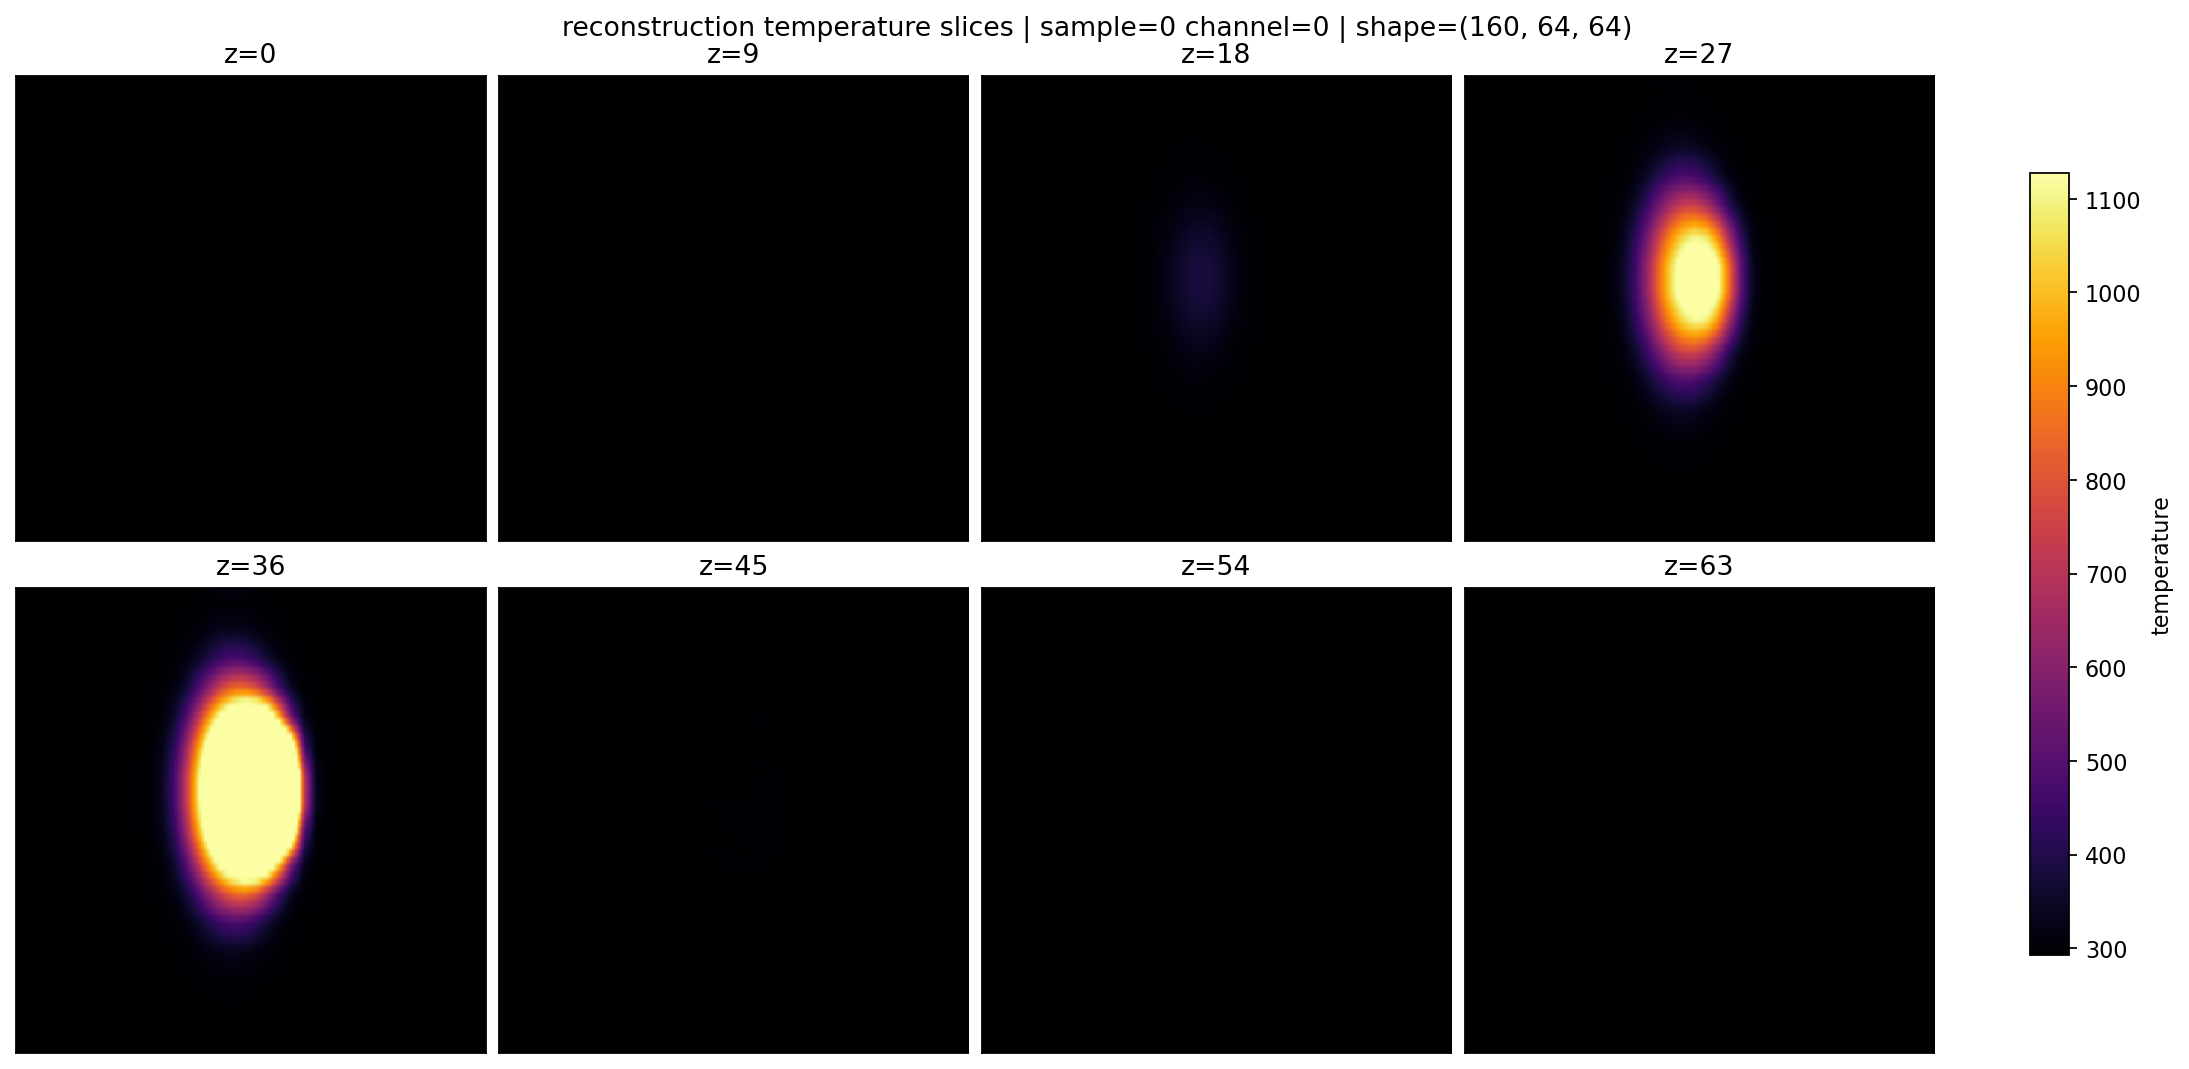

In [10]:
def plot_vae_slice_montage(source="reconstruction", axis="z", sample_index=0, channel_index=0, count=8):
    if spatial_dims != 3:
        print("3D slice montages are available only for VAE3D runs.")
        return
    volume, label, data_type, sample_index, channel_index, is_error = resolve_volume_source(source, sample_index, channel_index)
    axis = axis.lower()
    axis_index = {"x": 0, "y": 1, "z": 2}[axis]
    count = max(1, min(int(count), volume.shape[axis_index]))
    indices = sorted(set(np.linspace(0, volume.shape[axis_index] - 1, count, dtype=int).tolist()))
    cmap, vmin, vmax, field_name = volume_plot_settings(dataset, data_type, channel_index, [volume], error=is_error)

    cols = min(4, len(indices))
    rows = int(np.ceil(len(indices) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.4 * cols, 3.2 * rows), dpi=160, squeeze=False, constrained_layout=True)
    last_im = None
    for ax, idx in zip(axes.ravel(), indices):
        image = slice_2d(volume, axis, idx)
        last_im = ax.imshow(image, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"{axis}={idx}")
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes.ravel()[len(indices):]:
        ax.axis("off")
    fig.suptitle(f"{label} {field_name} slices | sample={sample_index} channel={channel_index} | shape={volume.shape}", y=1.02)
    if last_im is not None:
        fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.8, label=field_name)
    plt.show()


plot_vae_slice_montage(
    source=VOLUME_SOURCE,
    axis=VOLUME_AXIS,
    sample_index=VOLUME_SAMPLE_INDEX,
    channel_index=VOLUME_CHANNEL_INDEX,
    count=VOLUME_SLICE_COUNT,
)


## Multi-Field VAE Review

Use this when a VAE checkpoint has one channel per physical field. The Ti64 run at `diffusionsr/runs/direct/vae3d/2026_06_03_08_34_00/standardize/n_steps_1` uses channels `temperature`, `liqlabel`, and `meltregion` with `upscaled_lr` input/target tensors.


channel  field                    target range              recon range           mae       max err
      0  temperature                 293..3554                283..3541        0.5339           111
      1  liqlabel                         0..1         -0.007732..1.012     0.0001054       0.07389
      2  meltregion              -1.863e-09..1         -0.009165..1.016     0.0005098         1.005


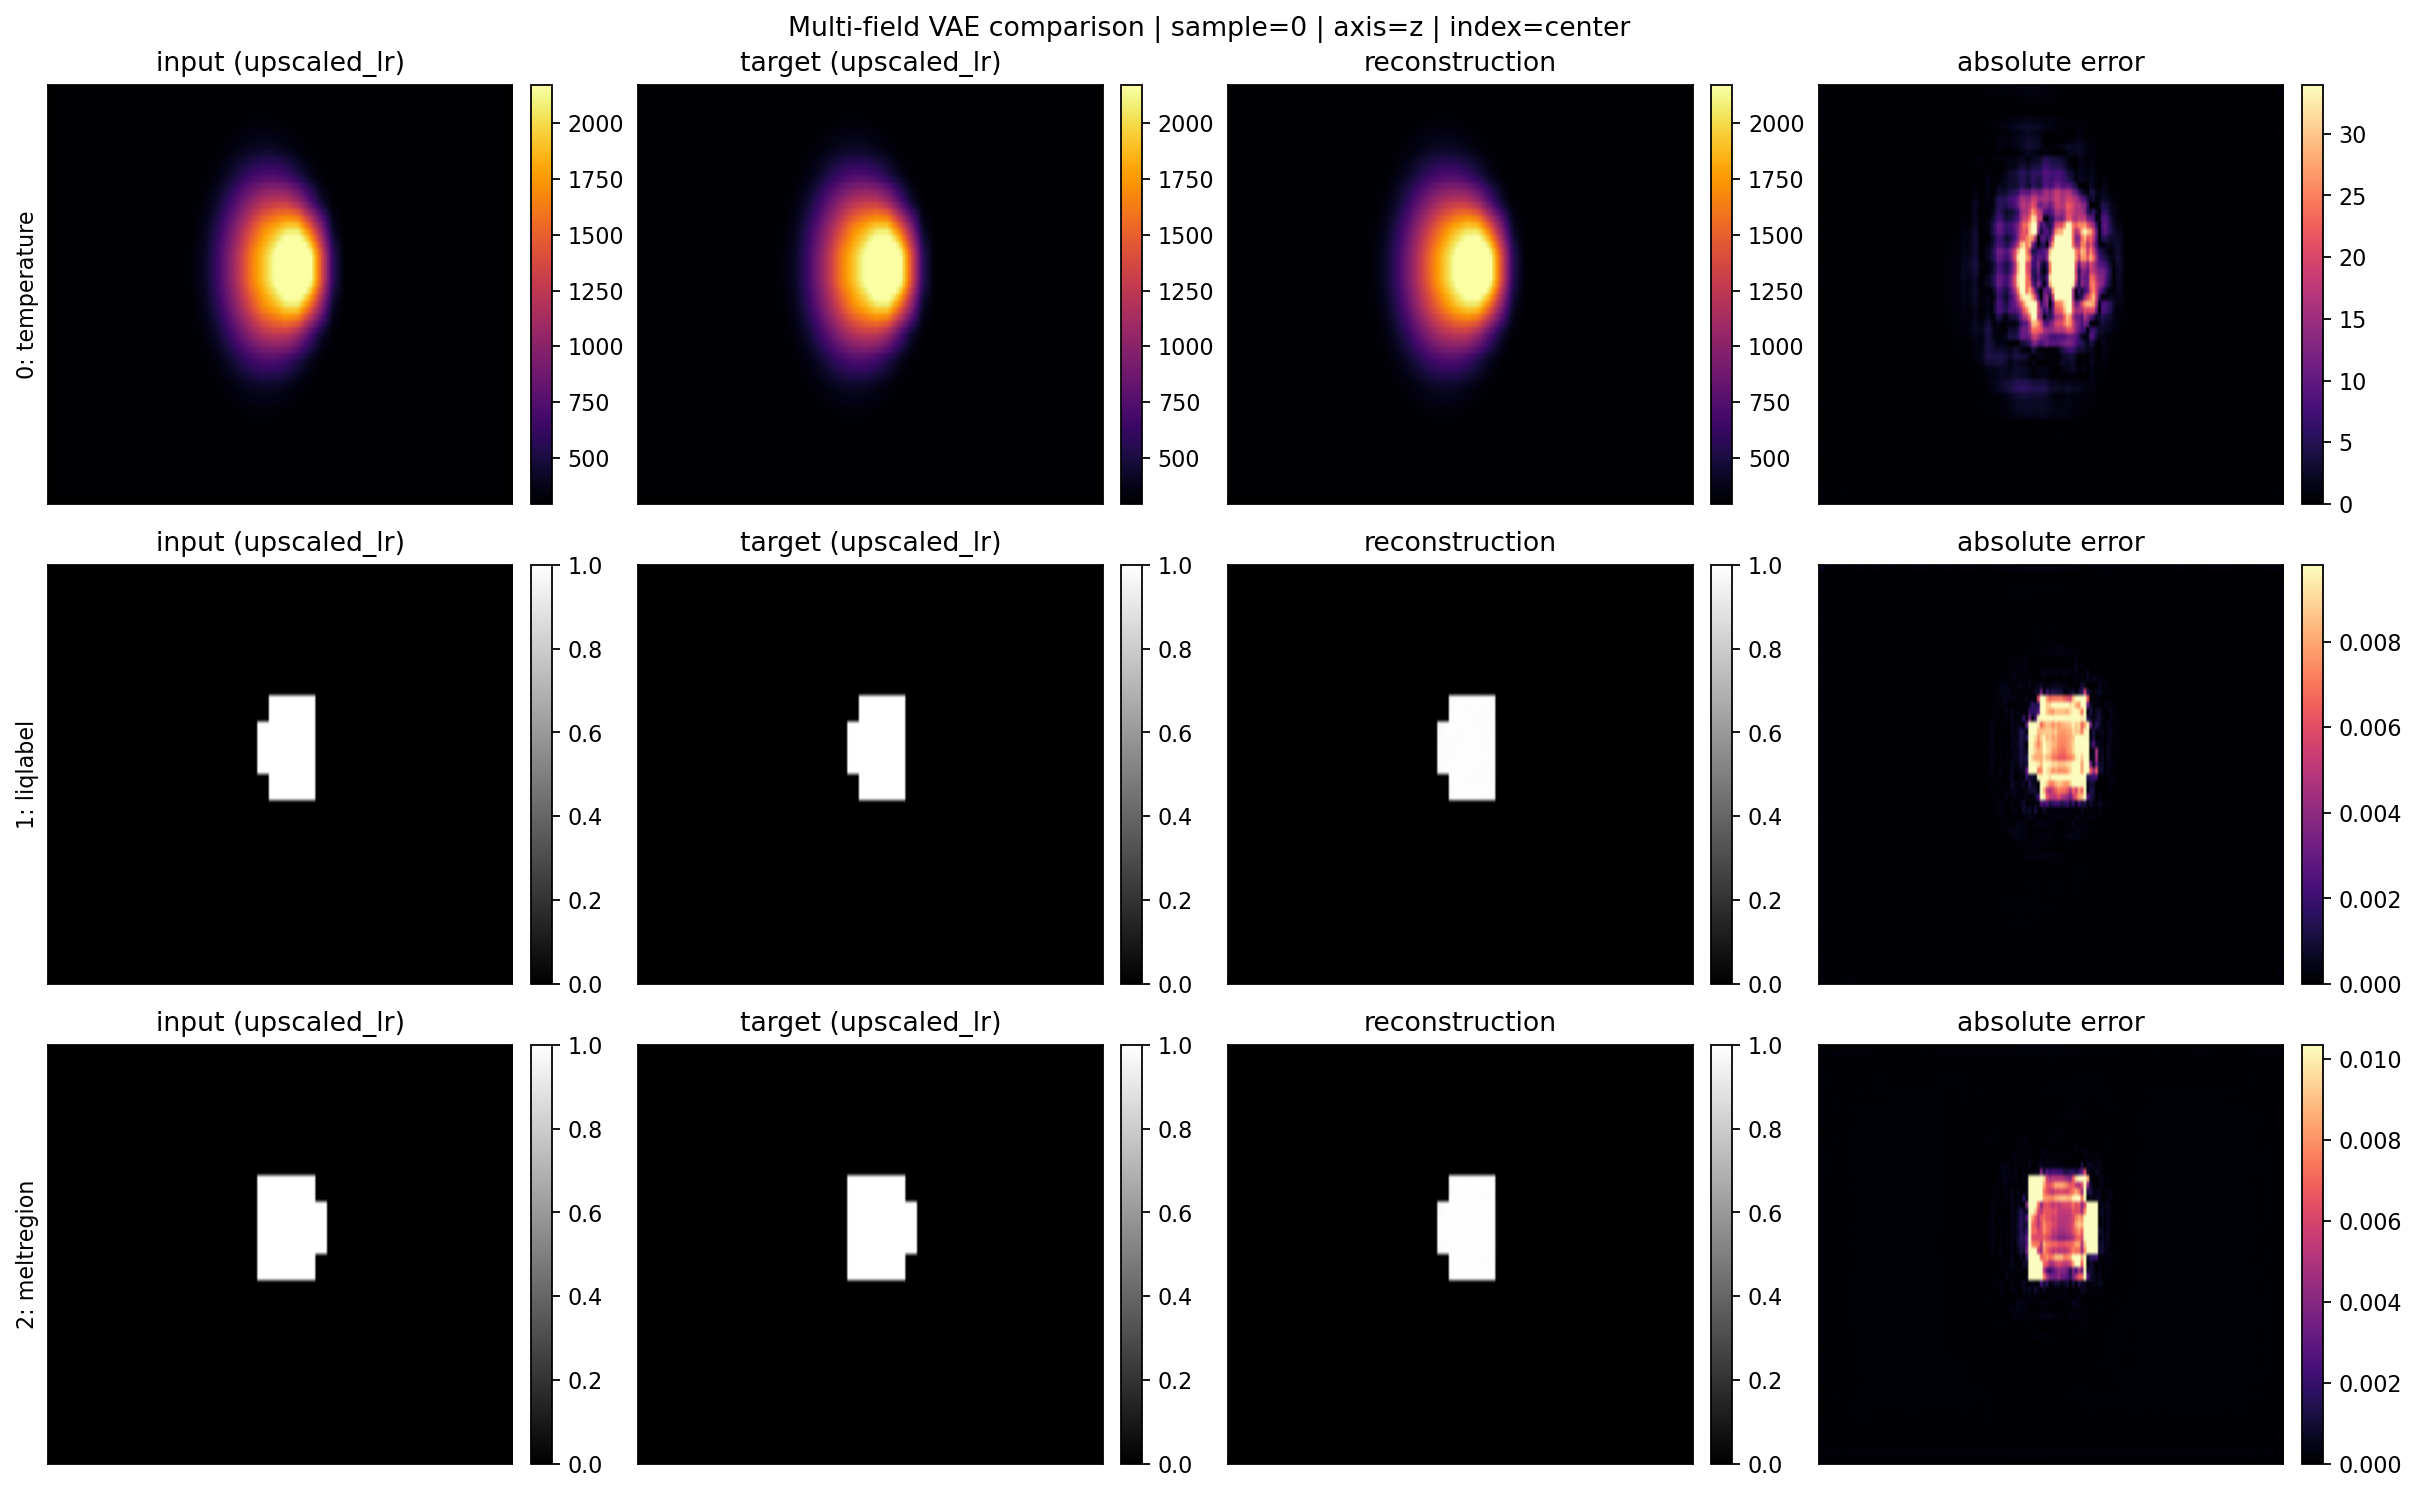

In [11]:
MULTIFIELD_SAMPLE_INDEX = SAMPLE_INDEX
MULTIFIELD_AXIS = "z"  # "x", "y", or "z" for 3D runs
MULTIFIELD_DEPTH_INDEX = DEPTH_INDEX
MULTIFIELD_FIELDS = None  # None plots every field, or use e.g. ["temperature", "meltregion"]
MULTIFIELD_MAX_FIELDS = None


def as_numpy(array):
    return array.detach().cpu().numpy() if torch.is_tensor(array) else np.asarray(array)


def available_field_channels(dataset, data, requested_fields=None, max_fields=None):
    values = as_numpy(data)
    field_names = list(getattr(dataset, "field_names", []) or [])
    if not field_names:
        field_names = [f"channel_{idx}" for idx in range(values.shape[1])]

    if isinstance(requested_fields, (str, int)):
        requested_fields = [requested_fields]
    requested = set(requested_fields or [])

    channels = []
    for channel_index in range(values.shape[1]):
        field_name = field_names[channel_index % len(field_names)]
        if requested and channel_index not in requested and field_name not in requested:
            continue
        channels.append((channel_index, field_name))
        if max_fields is not None and len(channels) >= int(max_fields):
            break
    return channels


def center_crop_to_common_rank(*arrays):
    arrays = [np.asarray(array) for array in arrays]
    ndim = arrays[0].ndim
    common_shape = tuple(min(array.shape[axis] for array in arrays) for axis in range(ndim))
    cropped = []
    for array in arrays:
        starts = [(array.shape[axis] - common_shape[axis]) // 2 for axis in range(ndim)]
        slices = tuple(slice(start, start + size) for start, size in zip(starts, common_shape))
        cropped.append(array[slices])
    return cropped


def selected_spatial_slice(data, sample_index=0, channel_index=0, axis="z", depth_index=None):
    values = as_numpy(data)
    sample_index = clamp_index(sample_index, values.shape[0])
    channel_index = clamp_index(channel_index, values.shape[1])
    volume_or_image = values[sample_index, channel_index]
    if volume_or_image.ndim == 2:
        return volume_or_image.T, sample_index, channel_index, None
    if volume_or_image.ndim != 3:
        raise ValueError(f"Expected 2D image or 3D volume, got shape {volume_or_image.shape}")

    axis = axis.lower()
    axis_index = {"x": 0, "y": 1, "z": 2}[axis]
    idx = center_indices(volume_or_image.shape)[axis_index] if depth_index is None else clamp_index(depth_index, volume_or_image.shape[axis_index])
    return slice_2d(volume_or_image, axis, idx), sample_index, channel_index, idx


def field_panel_settings(data_type, channel_index, arrays=None, error=False):
    field_name = field_name_for_channel(dataset, channel_index)
    if error:
        _, vmax = finite_percentile_limits(arrays or [], (0, 99))
        return "magma", 0.0, vmax, field_name
    if spatial_dims == 3:
        return volume_plot_settings(dataset, data_type, channel_index, arrays, error=False)
    return display_settings(dataset, data_type, channel_index)


def print_multifield_vae_summary(sample_index=0, requested_fields=None, max_fields=None):
    values_target = as_numpy(target_unscaled)
    values_recon = as_numpy(reconstruction_unscaled)
    sample_index = clamp_index(sample_index, values_target.shape[0])
    channels = available_field_channels(dataset, values_target, requested_fields=requested_fields, max_fields=max_fields)
    print(f"{'channel':>7}  {'field':<12}  {'target range':>23}  {'recon range':>23}  {'mae':>12}  {'max err':>12}")
    for channel_index, field_name in channels:
        target_array = values_target[sample_index, channel_index]
        recon_array = values_recon[sample_index, channel_index]
        target_array, recon_array = center_crop_to_common_rank(target_array, recon_array)
        error = np.abs(recon_array - target_array)
        target_range = f"{np.nanmin(target_array):.4g}..{np.nanmax(target_array):.4g}"
        recon_range = f"{np.nanmin(recon_array):.4g}..{np.nanmax(recon_array):.4g}"
        print(
            f"{channel_index:7d}  {field_name:<12}  {target_range:>23}  {recon_range:>23}  "
            f"{float(np.nanmean(error)):12.4g}  {float(np.nanmax(error)):12.4g}"
        )


def plot_multifield_vae_comparison(axis="z", sample_index=0, depth_index=None, requested_fields=None, max_fields=None):
    channels = available_field_channels(dataset, target_unscaled, requested_fields=requested_fields, max_fields=max_fields)
    if not channels:
        print("No matching fields to plot.")
        return

    fig, axes = plt.subplots(
        len(channels),
        4,
        figsize=(15, max(3.0, 3.0 * len(channels))),
        dpi=160,
        squeeze=False,
        constrained_layout=True,
    )
    for row, (channel_index, field_name) in enumerate(channels):
        input_image, sample_index, _, used_depth = selected_spatial_slice(
            model_input_unscaled,
            sample_index=sample_index,
            channel_index=channel_index,
            axis=axis,
            depth_index=depth_index,
        )
        target_image, _, _, _ = selected_spatial_slice(
            target_unscaled,
            sample_index=sample_index,
            channel_index=channel_index,
            axis=axis,
            depth_index=depth_index,
        )
        recon_image, _, _, _ = selected_spatial_slice(
            reconstruction_unscaled,
            sample_index=sample_index,
            channel_index=channel_index,
            axis=axis,
            depth_index=depth_index,
        )
        target_for_error, recon_for_error = center_crop_to_common_rank(target_image, recon_image)
        error_image = np.abs(recon_for_error - target_for_error)

        shared_cmap, shared_vmin, shared_vmax, _ = field_panel_settings(
            target_type,
            channel_index,
            [input_image, target_image, recon_image],
        )
        err_cmap, err_vmin, err_vmax, _ = field_panel_settings(
            target_type,
            channel_index,
            [error_image],
            error=True,
        )
        panels = [
            (f"input ({input_type})", input_image, shared_cmap, shared_vmin, shared_vmax),
            (f"target ({target_type})", target_image, shared_cmap, shared_vmin, shared_vmax),
            ("reconstruction", recon_image, shared_cmap, shared_vmin, shared_vmax),
            ("absolute error", error_image, err_cmap, err_vmin, err_vmax),
        ]
        for ax, (title, image, cmap, vmin, vmax) in zip(axes[row], panels):
            im = ax.imshow(image, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_title(title)
            ax.set_xticks([])
            ax.set_yticks([])
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        axes[row, 0].set_ylabel(f"{channel_index}: {field_name}")

    subtitle = f"sample={sample_index}"
    if spatial_dims == 3:
        subtitle += f" | axis={axis} | index={used_depth if depth_index is not None else 'center'}"
    fig.suptitle(f"Multi-field VAE comparison | {subtitle}", y=1.02)
    plt.show()


print_multifield_vae_summary(
    sample_index=MULTIFIELD_SAMPLE_INDEX,
    requested_fields=MULTIFIELD_FIELDS,
    max_fields=MULTIFIELD_MAX_FIELDS,
)
plot_multifield_vae_comparison(
    axis=MULTIFIELD_AXIS,
    sample_index=MULTIFIELD_SAMPLE_INDEX,
    depth_index=MULTIFIELD_DEPTH_INDEX,
    requested_fields=MULTIFIELD_FIELDS,
    max_fields=MULTIFIELD_MAX_FIELDS,
)


## 3D Multi-Field Cross-Section Grid

Rows show orthogonal center cross sections and columns show the selected physical fields. This gives a compact 9-panel view for three-field VAE3D checkpoints.


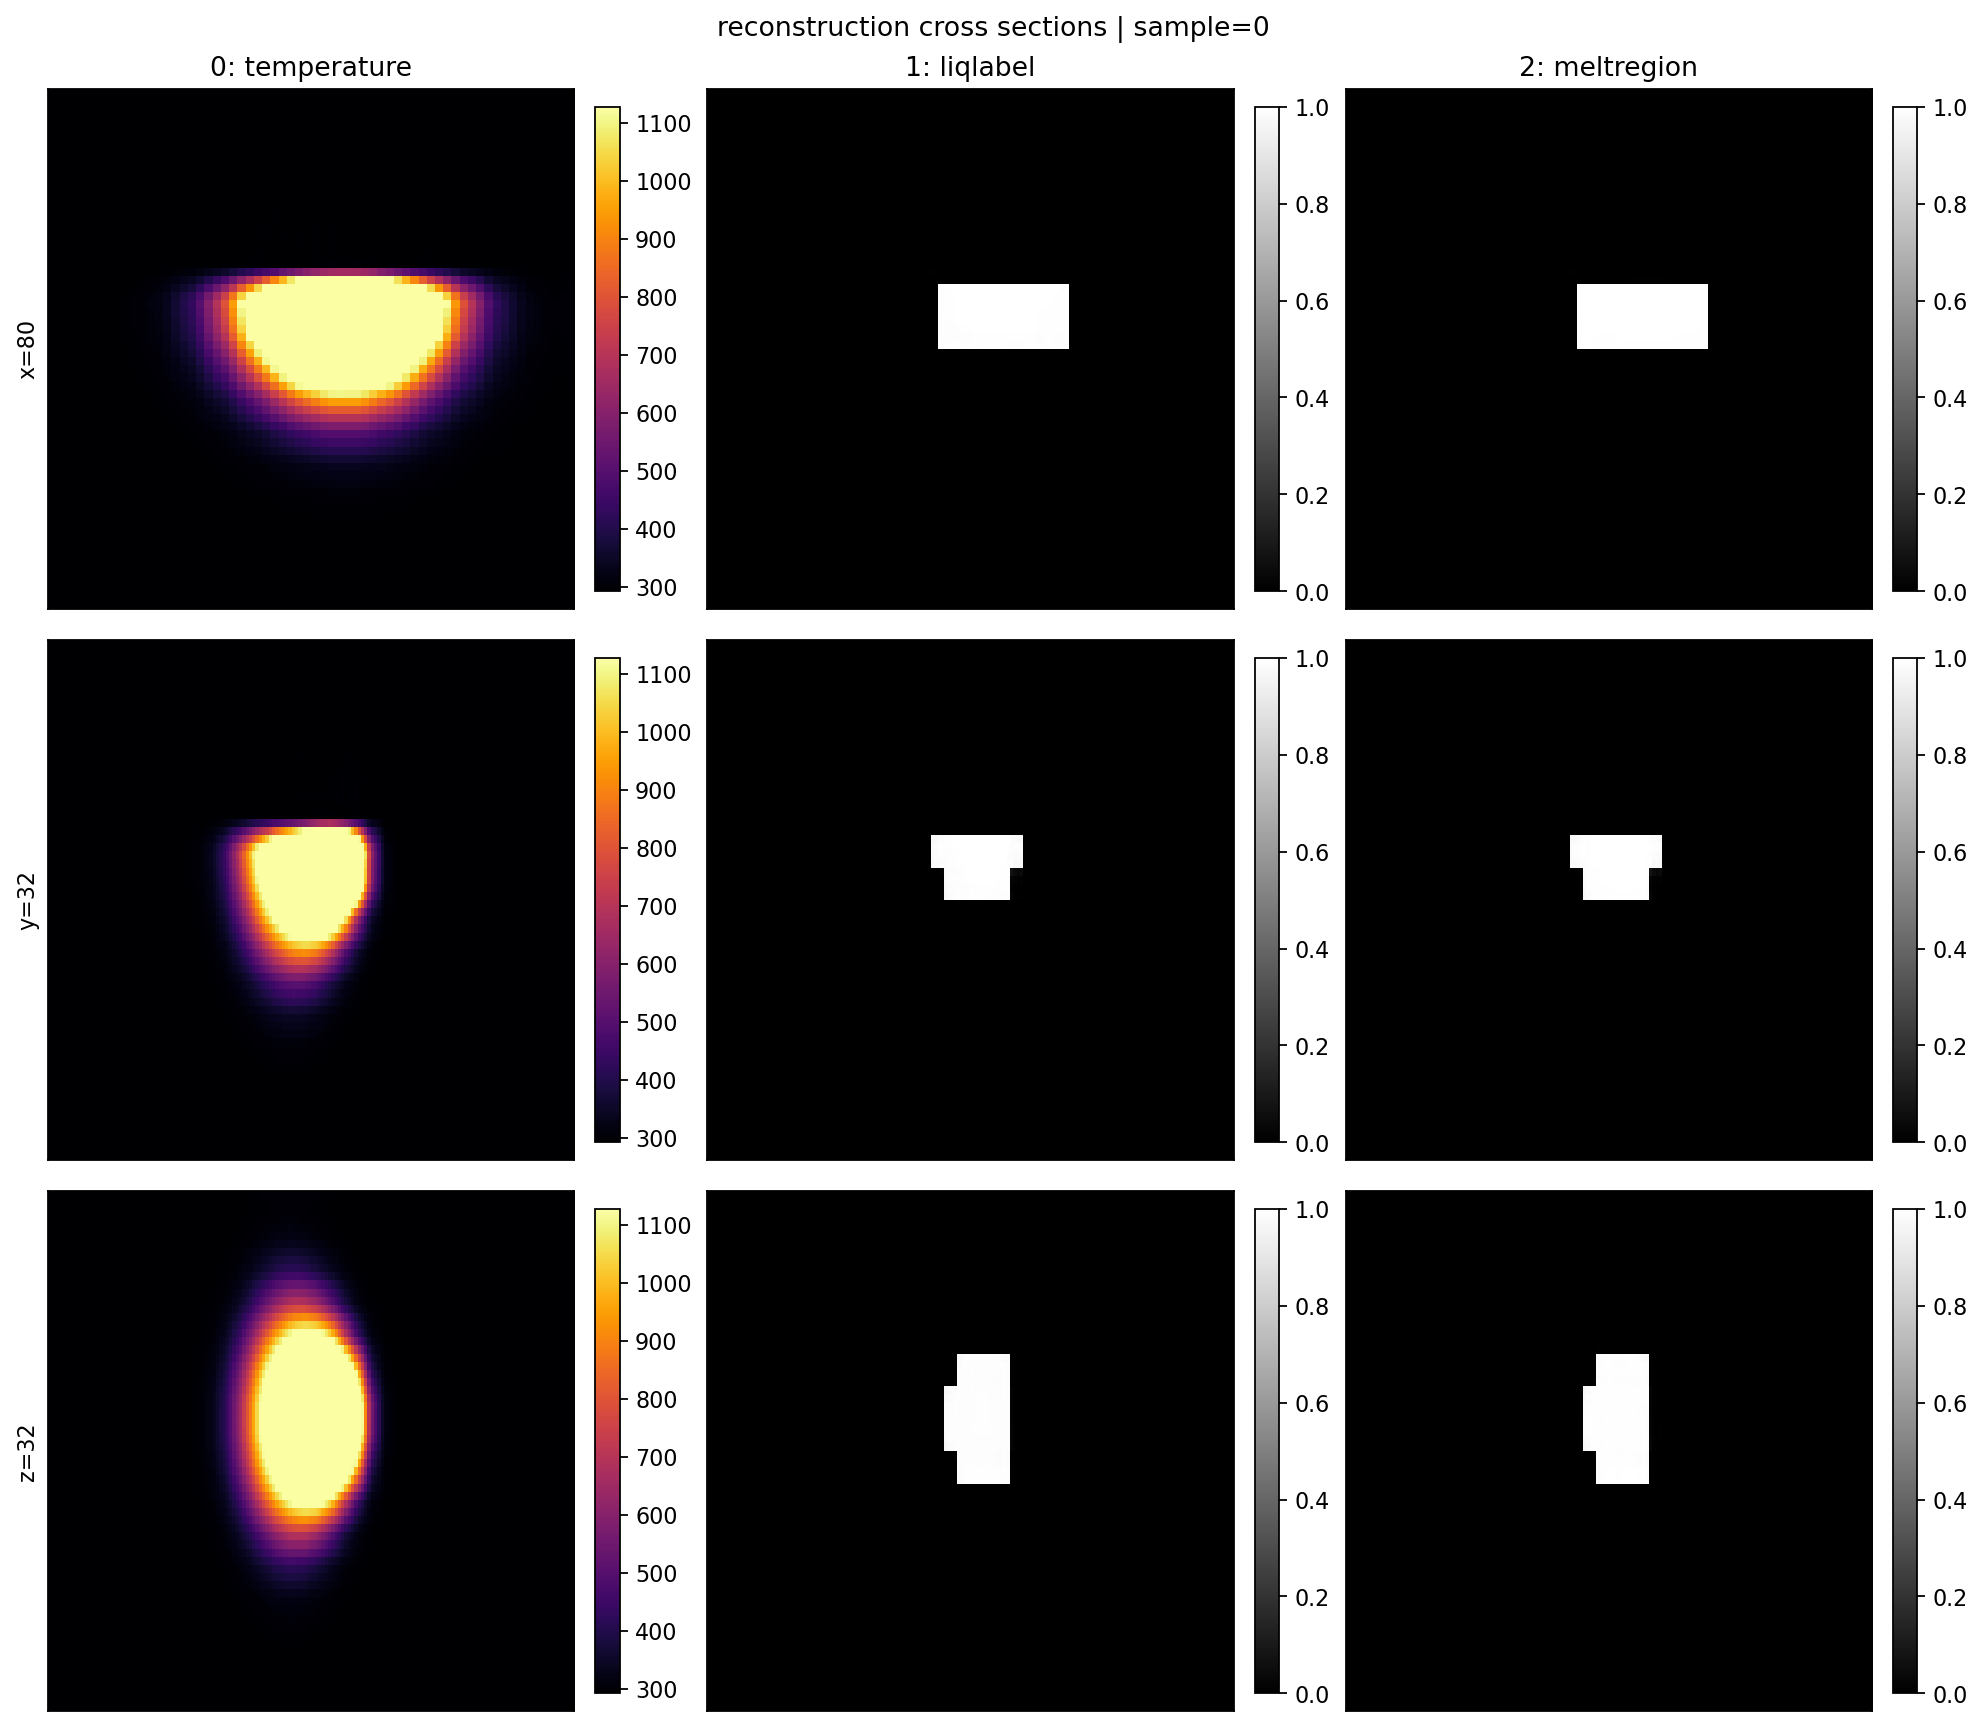

In [15]:
GRID_SOURCE = "reconstruction"  # "input", "target", "reconstruction", or "error"
GRID_SAMPLE_INDEX = SAMPLE_INDEX
GRID_FIELDS = ["temperature", "liqlabel", "meltregion"]  # None uses the first three channels
GRID_AXIS_ORDER = ("x", "y", "z")
GRID_DEPTH_INDEXES = {"x": None, "y": None, "z": None}  # None uses the center slice for each axis


def selected_grid_channels(dataset, data, requested_fields=None, count=3):
    channels = available_field_channels(dataset, data, requested_fields=requested_fields, max_fields=count)
    if len(channels) < count and requested_fields is not None:
        print(f"Requested {count} fields but found {len(channels)} matching channel(s): {channels}")
    return channels[:count]


def grid_axis_index(volume, axis, depth_indexes=None):
    axis = axis.lower()
    axis_index = {"x": 0, "y": 1, "z": 2}[axis]
    depth_indexes = depth_indexes or {}
    requested_index = depth_indexes.get(axis)
    if requested_index is None:
        return center_indices(volume.shape)[axis_index]
    return clamp_index(requested_index, volume.shape[axis_index])


def plot_multifield_cross_section_grid(
    source="reconstruction",
    sample_index=0,
    requested_fields=None,
    axis_order=("x", "y", "z"),
    depth_indexes=None,
):
    if spatial_dims != 3:
        print("The multi-field cross-section grid is available only for VAE3D runs.")
        return

    channels = selected_grid_channels(dataset, target_unscaled, requested_fields=requested_fields, count=3)
    if not channels:
        print("No matching fields to plot.")
        return

    axis_order = tuple(axis.lower() for axis in axis_order)
    fig, axes = plt.subplots(
        len(axis_order),
        len(channels),
        figsize=(4.1 * len(channels), 3.5 * len(axis_order)),
        dpi=160,
        squeeze=False,
        constrained_layout=True,
    )

    source_label = None
    for col, (channel_index, field_name) in enumerate(channels):
        volume, source_label, data_type, sample_index, channel_index, is_error = resolve_volume_source(
            source,
            sample_index=sample_index,
            channel_index=channel_index,
        )
        cmap, vmin, vmax, _ = volume_plot_settings(dataset, data_type, channel_index, [volume], error=is_error)
        for row, axis in enumerate(axis_order):
            idx = grid_axis_index(volume, axis, depth_indexes=depth_indexes)
            image = slice_2d(volume, axis, idx)
            ax = axes[row, col]
            im = ax.imshow(image, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
            if row == 0:
                ax.set_title(f"{channel_index}: {field_name}")
            if col == 0:
                ax.set_ylabel(f"{axis}={idx}")
            ax.set_xticks([])
            ax.set_yticks([])
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"{source_label} cross sections | sample={sample_index}", y=1.02)
    plt.show()


plot_multifield_cross_section_grid(
    source=GRID_SOURCE,
    sample_index=GRID_SAMPLE_INDEX,
    requested_fields=GRID_FIELDS,
    axis_order=GRID_AXIS_ORDER,
    depth_indexes=GRID_DEPTH_INDEXES,
)


## Latent View

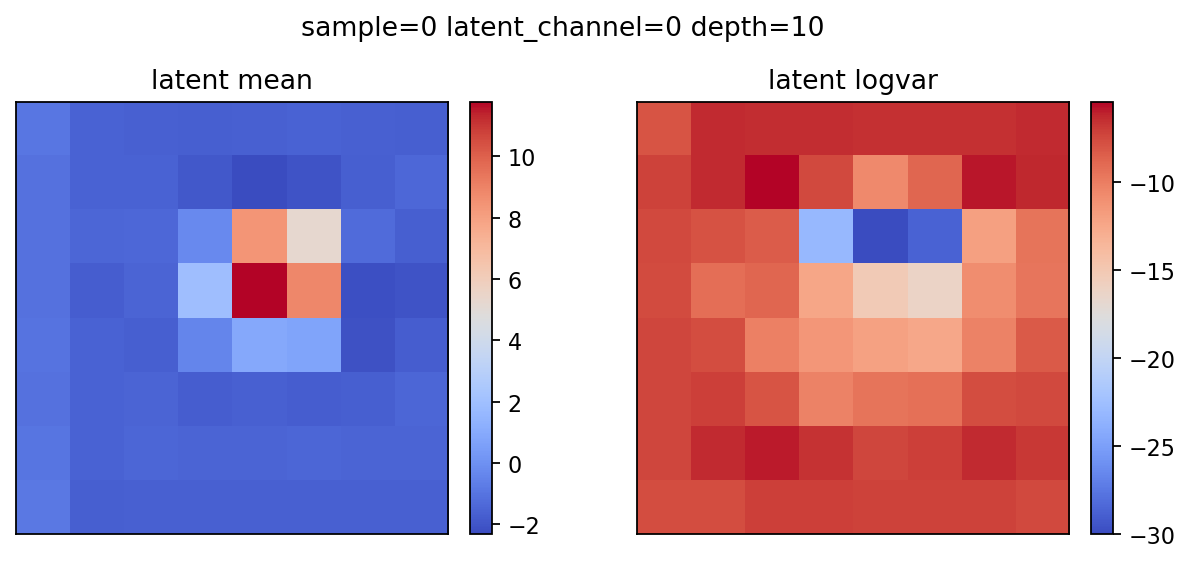

In [12]:
latent_slice, latent_depth, latent_sample_idx, latent_channel_idx = display_slice(
    output.mu,
    SAMPLE_INDEX,
    LATENT_CHANNEL_INDEX,
    DEPTH_INDEX,
)
logvar_slice, _, _, _ = display_slice(
    output.logvar,
    SAMPLE_INDEX,
    LATENT_CHANNEL_INDEX,
    DEPTH_INDEX,
)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), dpi=160)
for ax, array, title in zip(axes, [latent_slice, logvar_slice], ["latent mean", "latent logvar"]):
    im = ax.imshow(array.T, origin="lower", cmap="coolwarm")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(
    f"sample={latent_sample_idx} latent_channel={latent_channel_idx}"
    + (f" depth={latent_depth}" if latent_depth is not None else "")
)
fig.tight_layout()
plt.show()


## Training Curves

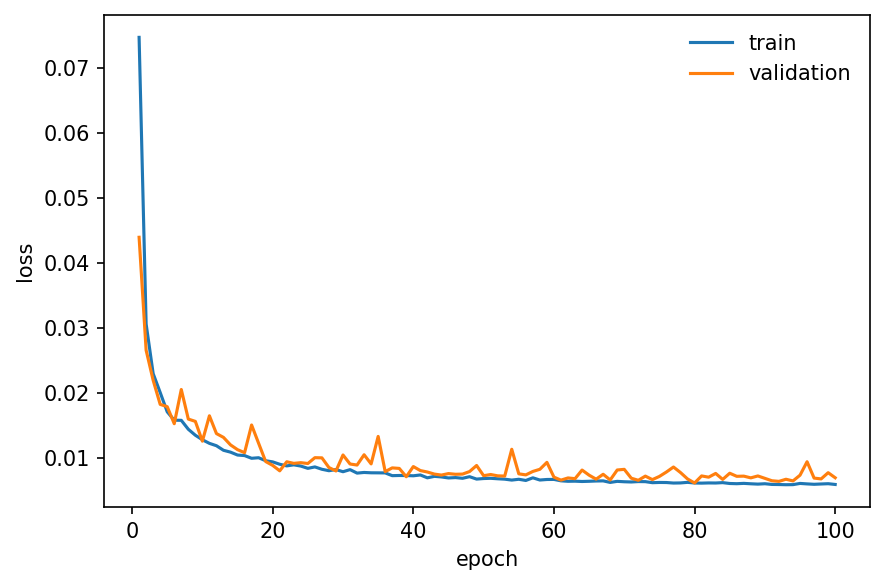

In [13]:
history_path = RUN_DIR / "history.csv"
if history_path.exists():
    with open(history_path, "r", newline="") as f:
        rows = list(csv.DictReader(f))
    epochs = [int(float(row["epoch"])) for row in rows]
    train_loss = [float(row["train/loss"]) for row in rows]
    val_loss = [float(row["validation/loss"]) for row in rows]
else:
    train_path = RUN_DIR / "loss_epoch.txt"
    val_path = RUN_DIR / "validation_loss_epoch.txt"
    train_loss = np.loadtxt(train_path).reshape(-1).tolist() if train_path.exists() else []
    val_loss = np.loadtxt(val_path).reshape(-1).tolist() if val_path.exists() else []
    epochs = list(range(1, max(len(train_loss), len(val_loss)) + 1))

if epochs:
    plt.figure(figsize=(6, 4), dpi=150)
    if train_loss:
        plt.plot(epochs[:len(train_loss)], train_loss, label="train")
    if val_loss:
        plt.plot(epochs[:len(val_loss)], val_loss, label="validation")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
else:
    print("No local history/loss files found in", RUN_DIR)


## Optional Latent Export

In [14]:
if EXPORT_LATENTS:
    export_path = RUN_DIR / f"vae_latents_{DATA_SPLIT}_batch_{BATCH_INDEX:04d}.npz"
    np.savez_compressed(
        export_path,
        model_input=model_input.detach().cpu().numpy(),
        target=target.detach().cpu().numpy(),
        reconstruction=output.reconstruction.detach().cpu().numpy(),
        model_input_unscaled=model_input_unscaled,
        target_unscaled=target_unscaled,
        reconstruction_unscaled=reconstruction_unscaled,
        mu=output.mu.detach().cpu().numpy(),
        logvar=output.logvar.detach().cpu().numpy(),
        input_type=np.array(input_type),
        target_type=np.array(target_type),
        checkpoint=np.array(str(CHECKPOINT_PATH)),
    )
    print(export_path)
else:
    print("Set EXPORT_LATENTS = True in the run-selection cell to write a compressed latent export.")


Set EXPORT_LATENTS = True in the run-selection cell to write a compressed latent export.
